# ETF Returns Overview

This notebook loads `returns.csv` and creates three visualizations:
1. Equal-weight portfolio cumulative return
2. SPY rolling 20-day volatility
3. Train/test split visualization


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [3]:
returns = pd.read_csv('returns.csv', index_col=0, parse_dates=True).sort_index()
returns.head()


,GLD,IWM,QQQ,SPY,TLT
Date,,,,,
2008-01-03,0.008332,-0.011105,0.004157,-0.000483,-0.001378
2008-01-04,-0.005155,-0.030599,-0.044847,-0.024812,0.000212
2008-01-07,-0.004238,0.002217,-0.004763,-0.000849,0.004339
2008-01-08,0.023434,-0.031351,-0.026293,-0.016281,-0.001162
2008-01-09,-0.002654,0.010089,0.021089,0.010455,0.001901


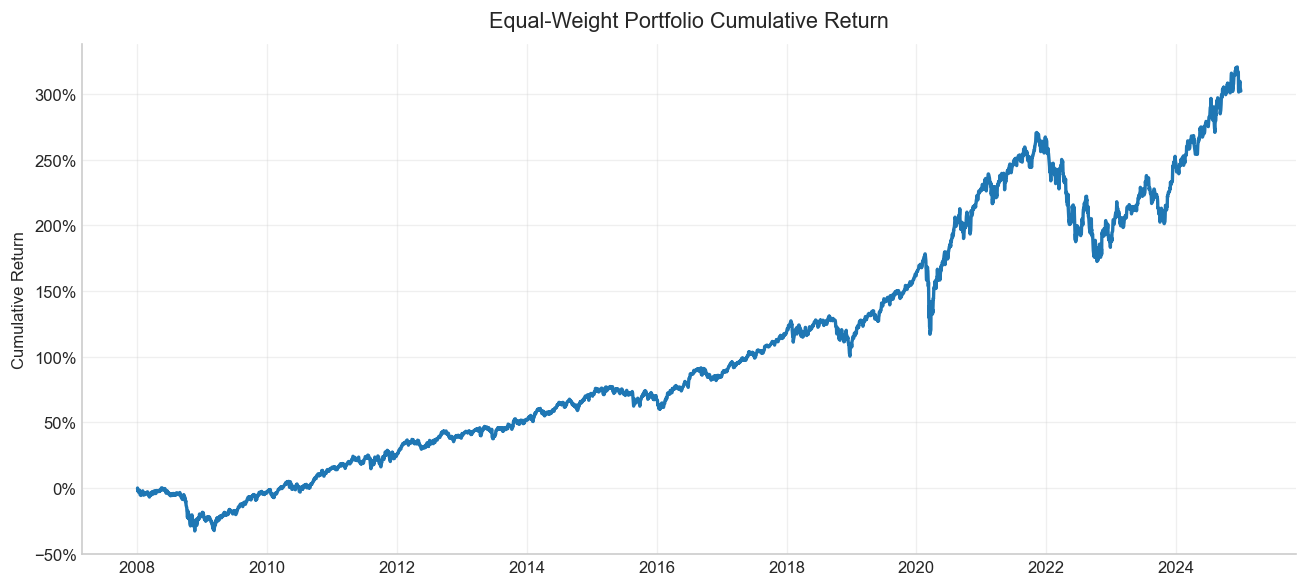

In [4]:
# Equal-weight portfolio: average of ETF daily log returns
ew_log_ret = returns.mean(axis=1)
ew_cum_ret = np.exp(ew_log_ret.cumsum()) - 1

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ew_cum_ret.index, ew_cum_ret, color='#1f77b4', linewidth=2)
ax.set_title('Equal-Weight Portfolio Cumulative Return', fontsize=13, pad=10)
ax.set_ylabel('Cumulative Return')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


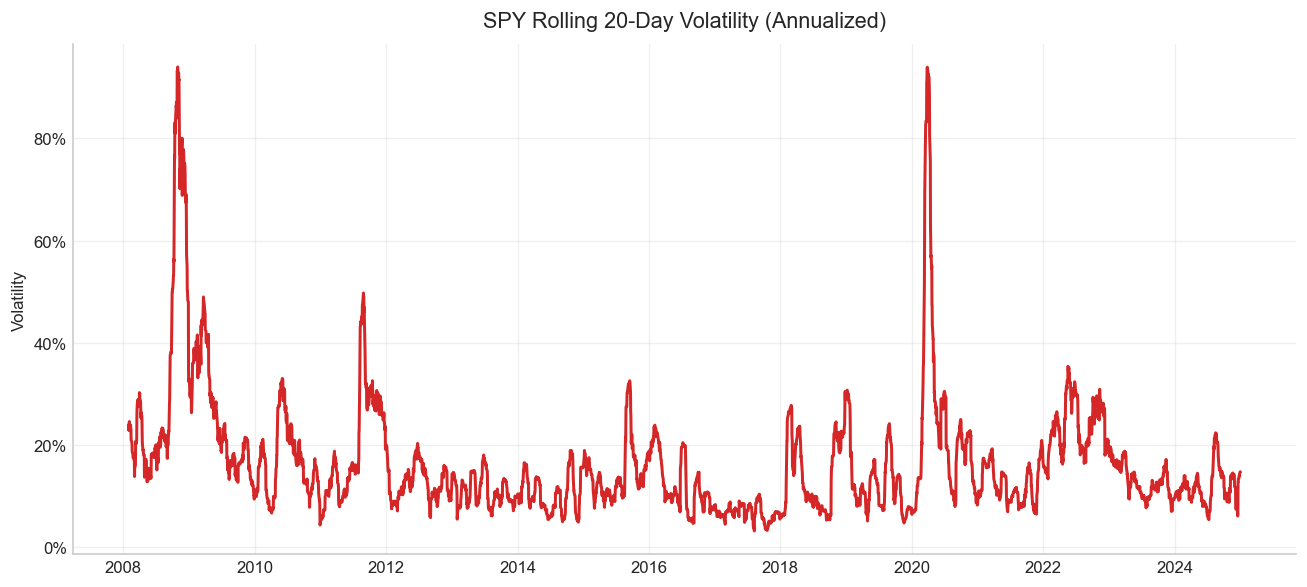

In [5]:
spy_vol20 = returns['SPY'].rolling(20).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(spy_vol20.index, spy_vol20, color='#d62728', linewidth=1.8)
ax.set_title('SPY Rolling 20-Day Volatility (Annualized)', fontsize=13, pad=10)
ax.set_ylabel('Volatility')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


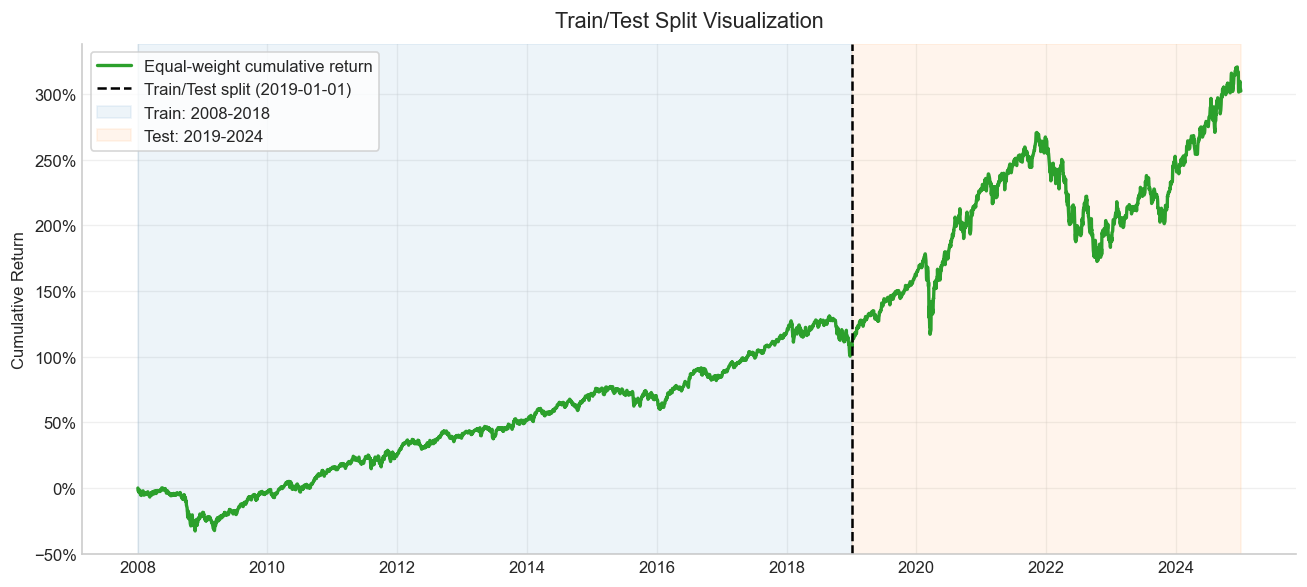

In [6]:
split_date = pd.Timestamp('2019-01-01')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ew_cum_ret.index, ew_cum_ret, color='#2ca02c', linewidth=2, label='Equal-weight cumulative return')
ax.axvline(split_date, color='black', linestyle='--', linewidth=1.5, label='Train/Test split (2019-01-01)')

ax.axvspan(pd.Timestamp('2008-01-01'), split_date, color='#1f77b4', alpha=0.08, label='Train: 2008-2018')
ax.axvspan(split_date, pd.Timestamp('2024-12-31'), color='#ff7f0e', alpha=0.08, label='Test: 2019-2024')

ax.set_title('Train/Test Split Visualization', fontsize=13, pad=10)
ax.set_ylabel('Cumulative Return')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', frameon=True)
fig.tight_layout()
plt.show()
